In [1]:
import numpy as np
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from ClassA import RFI_MakeEnvelopeDataClassA
from Estimadores import *
from matplotlib.gridspec import GridSpec

mpl.rc('font',family = 'Times New Roman')

In [55]:
#-------------------------------------------
#----------------- Parámetros --------------
#r = np.array([0.0001, 0.001, 0.01, 0.1, 1, 2])
#A = np.array([0.0001, 0.001, 0.01, 0.1, 1, 2])
r = 0.1
A = 0.1
Sigma_G_sq = 0.001
#-------------------------------------------
#-------------------------------------------
N_vec = 1000
N = 1000
#-----------------------------------
#-----------------------------------

In [57]:
# Inicializacion del vector A_ini
vec_A_ini       = np.zeros(N_vec)
vec_r_ini       = np.zeros(N_vec)
vec_Sigmag2_ini = np.zeros(N_vec)

# Inicializacion de los vectores INEMM
A_est_INEMM       = np.zeros(N_vec)
Sigmag2_est_INEMM = np.zeros(N_vec)
r_est_INEMM       = np.zeros(N_vec)
Numiter_INEMM     = np.zeros(N_vec)

for i in range(N_vec):
    if i == 100:
        print (i)
        
    env_data_Norm,env_data_DesNorm = RFI_MakeEnvelopeDataClassA(A,r,15,N,Sigma_G_sq)

    # Estimador inicial
    A_ini,Sigmag2_ini,r_ini = est_inicial(env_data_DesNorm)
    vec_A_ini[i]          = A_ini
    vec_Sigmag2_ini[i]    = Sigmag2_ini
    vec_r_ini[i]          = r_ini

    # Estimador INEMM
    A_est_INEMM[i],Sigmag2_est_INEMM[i],r_est_INEMM[i],Numiter_INEMM[i] = Est_Param_ClassA_CDF(env_data_DesNorm,[A_ini,Sigmag2_ini,r_ini],500,0.0001)

100


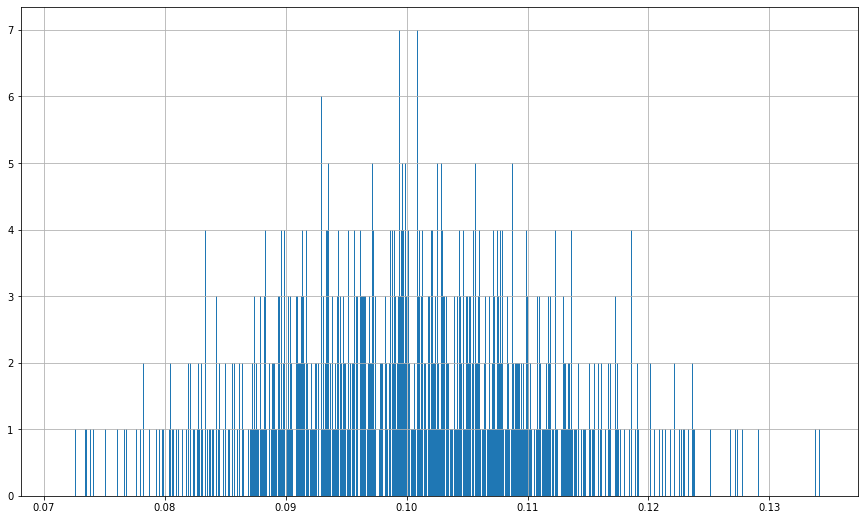

In [67]:
#histo, bin_edge = np.histogram(A_est_INEMM,bins=N_vec,density = False)
plt.figure(figsize=(15, 9))
plt.hist(A_est_INEMM,bins=1000,density=False)
plt.grid(True)
plt.show()

In [65]:
import numpy as np
from scipy.stats import shapiro
import matplotlib.pyplot as plt

# Verificar independencia de las estimaciones
correlacion = np.corrcoef(A_est_INEMM, rowvar=False)
print("Correlación entre las estimaciones:")
print(correlacion)

Correlación entre las estimaciones:
1.0


Resultado de la prueba de Shapiro-Wilk:
Estadístico de prueba: 0.9987138509750366
Valor p: 0.6978863477706909


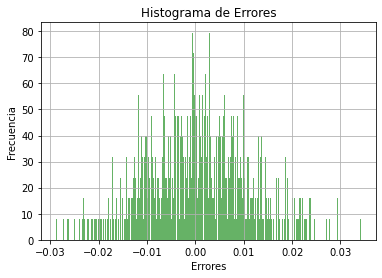

In [74]:
# Verificar normalidad de los errores
erroresA = A_est_INEMM - A
shapiro_test_statistic, shapiro_p_value = shapiro(erroresA)
print("Resultado de la prueba de Shapiro-Wilk:")
print("Estadístico de prueba:", shapiro_test_statistic)
print("Valor p:", shapiro_p_value)

# Histograma de los errores
plt.hist(erroresA, bins=500, density=True, alpha=0.6, color='g')
plt.xlabel('Errores')
plt.ylabel('Frecuencia')
plt.title('Histograma de Errores')
plt.grid(True)
plt.show()


Resultado de la prueba de Shapiro-Wilk:
Estadístico de prueba: 0.9821820855140686
Valor p: 1.042102626414021e-09


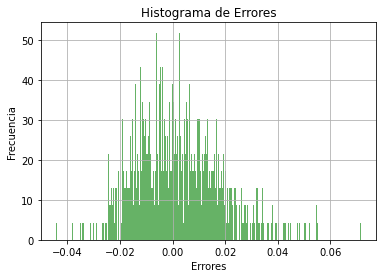

In [75]:
# Verificar normalidad de los errores en r
erroresr = r_est_INEMM - r
shapiro_test_statistic, shapiro_p_value = shapiro(erroresr)
print("Resultado de la prueba de Shapiro-Wilk:")
print("Estadístico de prueba:", shapiro_test_statistic)
print("Valor p:", shapiro_p_value)

# Histograma de los errores
plt.hist(erroresr, bins=500, density=True, alpha=0.6, color='g')
plt.xlabel('Errores')
plt.ylabel('Frecuencia')
plt.title('Histograma de Errores')
plt.grid(True)
plt.show()